# 01 - ENTENDER LOS DATOS
Entender la lógica del negocio y del experimento A/B de Vanguard.

## 1. CARGAR LIBRERÍAS

In [1]:
#Pathlib sirve para que todos podamos trabajar desde cualquier sistema operativo.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path().resolve().parent
DATA_PATH = ROOT / "data_raw"

print("Directorio actual:", ROOT)
print("Ruta de datos:", DATA_PATH)

Directorio actual: C:\Users\erika\OneDrive\Escritorio\DAFT2026\Data Analitycs\SEMANA5\Projecto-2-Vanguard-ab-test
Ruta de datos: C:\Users\erika\OneDrive\Escritorio\DAFT2026\Data Analitycs\SEMANA5\Projecto-2-Vanguard-ab-test\data_raw


## 2. CARGAR DATASETS

Usamos rutas relativas para que funcione en cualquier ordenador.
Este notebook debe estar en la carpeta `notebooks/` y los datos en `data/raw/`.

In [3]:
# Rutas relativas (funcionan en Windows, Mac y Linux)
df_demo        = pd.read_csv(DATA_PATH / "df_final_demo.txt")
df_experiment  = pd.read_csv(DATA_PATH / "df_final_experiment_clients.txt")
df_web_pt1     = pd.read_csv(DATA_PATH / "df_final_web_data_pt_1.txt")
df_web_pt2     = pd.read_csv(DATA_PATH / "df_final_web_data_pt_2.txt")

print("Datos cargados correctamente!")

Datos cargados correctamente!


Erika a Gabriel: Esto no solo lo he modificado para que lo podamos leer todos, sino porque en el original que me pasastes, los archivos estaban cargados
con los nombres cambiados, por ejemplo: "df_experiment = pd.read_csv("...df_final_web_data_pt_2.txt"), eso hace que el código lea web data en vez de experiment .

## 3. VERIFICAR TAMAÑO DE LOS DATASETS

In [4]:
print("df_demo shape:       ", df_demo.shape)        # Perfiles de clientes
print("df_experiment shape: ", df_experiment.shape)  # Grupo Test/Control
print("df_web_pt1 shape:    ", df_web_pt1.shape)     # Interacciones web parte 1
print("df_web_pt2 shape:    ", df_web_pt2.shape)     # Interacciones web parte 2

df_demo shape:        (70609, 9)
df_experiment shape:  (70609, 2)
df_web_pt1 shape:     (343141, 5)
df_web_pt2 shape:     (412264, 5)


## 4. PRIMERAS FILAS DE CADA DATASET

In [5]:
# DEMO: información demográfica (edad, género, cuentas, balances, antigüedad)
df_demo.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [6]:
# Erika a Gabriel: ordeno un poco mejor el orden: EXPERIMENT: clientes que participaron del experimento A/B (Test/Control)
df_experiment.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [7]:
# WEB PT1: interacciones online de clientes (parte 1)
df_web_pt1.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [8]:
# WEB PT2: interacciones online de clientes (parte 2)
df_web_pt2.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
1,6019349,442094451_91531546617,154620534_35331068705_522317,confirm,2017-06-01 11:59:27
2,6019349,442094451_91531546617,154620534_35331068705_522317,step_3,2017-06-01 11:58:48
3,6019349,442094451_91531546617,154620534_35331068705_522317,step_2,2017-06-01 11:58:08
4,6019349,442094451_91531546617,154620534_35331068705_522317,step_1,2017-06-01 11:57:58


## 5. INFORMACIÓN DE COLUMNAS Y TIPOS DE DATOS

In [9]:
print("=== df_demo ===")
df_demo.info()

=== df_demo ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70609 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70595 non-null  object 
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 4.8+ MB


In [10]:
print("=== df_experiment ===")
df_experiment.info()

=== df_experiment ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  70609 non-null  int64 
 1   Variation  50500 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.1+ MB


In [11]:
print("=== df_web_pt1 ===")
df_web_pt1.info()

=== df_web_pt1 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343141 entries, 0 to 343140
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   client_id     343141 non-null  int64 
 1   visitor_id    343141 non-null  object
 2   visit_id      343141 non-null  object
 3   process_step  343141 non-null  object
 4   date_time     343141 non-null  object
dtypes: int64(1), object(4)
memory usage: 13.1+ MB


In [12]:
print("=== df_web_pt2 ===")
df_web_pt2.info()

=== df_web_pt2 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412264 entries, 0 to 412263
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   client_id     412264 non-null  int64 
 1   visitor_id    412264 non-null  object
 2   visit_id      412264 non-null  object
 3   process_step  412264 non-null  object
 4   date_time     412264 non-null  object
dtypes: int64(1), object(4)
memory usage: 15.7+ MB


## 6. ESTADÍSTICAS GENERALES

In [13]:
# df_demo: estadísticas numéricas (edad media, antigüedad, balance...)
df_demo.describe()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,7.060900e+04,70595.000000,70595.000000,70594.000000,70595.000000,7.059500e+04,70595.000000,70595.000000
mean,5.004992e+06,12.052950,150.659367,46.442240,2.255528,1.474452e+05,3.382478,5.566740
std,2.877278e+06,6.871819,82.089854,15.591273,0.534997,3.015087e+05,2.236580,2.353286
min,1.690000e+02,2.000000,33.000000,13.500000,1.000000,1.378942e+04,0.000000,1.000000
25%,2.519329e+06,6.000000,82.000000,32.500000,2.000000,3.734683e+04,1.000000,4.000000
50%,5.016978e+06,11.000000,136.000000,47.000000,2.000000,6.333290e+04,3.000000,5.000000
75%,7.483085e+06,16.000000,192.000000,59.000000,2.000000,1.375449e+05,6.000000,7.000000
max,9.999839e+06,62.000000,749.000000,96.000000,8.000000,1.632004e+07,7.000000,9.000000


## 7. REVISIÓN DE NULOS

In [14]:
print("Nulos en df_demo:")
print(df_demo.isna().sum())
print()
print("Nulos en df_experiment:")
print(df_experiment.isna().sum())
print()
print("Nulos en df_web_pt1:")
print(df_web_pt1.isna().sum())
print()
print("Nulos en df_web_pt2:")
print(df_web_pt2.isna().sum())

Nulos en df_demo:
client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64

Nulos en df_experiment:
client_id        0
Variation    20109
dtype: int64

Nulos en df_web_pt1:
client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

Nulos en df_web_pt2:
client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64


## 8. REVISIÓN DE DUPLICADOS

In [15]:
print("Duplicados en df_demo:       ", df_demo.duplicated().sum())
print("Duplicados en df_experiment: ", df_experiment.duplicated().sum())
print("Duplicados en df_web_pt1:    ", df_web_pt1.duplicated().sum())
print("Duplicados en df_web_pt2:    ", df_web_pt2.duplicated().sum())

Duplicados en df_demo:        0
Duplicados en df_experiment:  0
Duplicados en df_web_pt1:     2095
Duplicados en df_web_pt2:     8669


## 9. UNIR df_web_pt1 y df_web_pt2

Según el enunciado del proyecto, hay que fusionar las dos partes del dataset web
en un único DataFrame antes de continuar con el análisis.

In [16]:
# Unir los dos datasets web verticalmente (mismo formato)
df_web = pd.concat([df_web_pt1, df_web_pt2], ignore_index=True)

print("df_web_pt1 filas: ", len(df_web_pt1))
print("df_web_pt2 filas: ", len(df_web_pt2))
print("df_web total:     ", len(df_web))
df_web.head()

df_web_pt1 filas:  343141
df_web_pt2 filas:  412264
df_web total:      755405


,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


## 10. DISTRIBUCIÓN TEST vs CONTROL

C:\Users\erika\AppData\Local\Temp\ipykernel_5696\3342109748.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_experiment, x="Variation", palette="Blues")


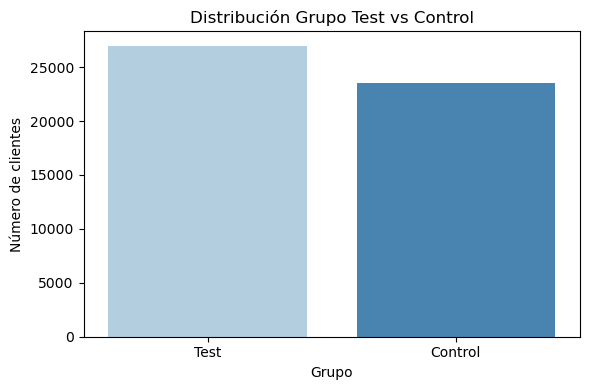

Variation
Test       26968
Control    23532
Name: count, dtype: int64


In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_experiment, x="Variation", palette="Blues")
plt.title("Distribución Grupo Test vs Control")
plt.xlabel("Grupo")
plt.ylabel("Número de clientes")
plt.tight_layout()
plt.show()

print(df_experiment["Variation"].value_counts())

## 11. RESUMEN INICIAL DE HALLAZGOS

**Datos encontrados:**
- `df_demo`: 70.609 clientes con información demográfica. ~14-15 nulos en varias columnas. Sin duplicados.
- `df_experiment`: 70.609 entradas. ~20.109 nulos en columna `Variation` (clientes fuera del experimento). Sin duplicados.
- `df_web_pt1`: 343.141 interacciones. Sin nulos. 2.095 duplicados a tratar.
- `df_web_pt2`: 412.264 interacciones. Sin nulos. 8.669 duplicados a tratar.
- `df_web` (merged): ~755.405 filas totales antes de limpiar duplicados.

**Próximos pasos (notebook 02 - Limpieza):**
- Eliminar duplicados en df_web
- Tratar nulos en df_demo
- Tratar nulos de Variation en df_experiment
- Convertir `date_time` a formato datetime
- Unir todos los datasets para el análisis 01_data_understanding_1.ipynb